# Causal Graph Comparison: `linear_no_conf` vs `linear_conf`

Structural analysis of the PC and LiNGAM discovered graphs across the two linear datasets.
Focus: which graph differences explain why Shapley methods align better with the Traditional baseline on the no-confounder dataset.

Sections:
1. Configuration & Imports
2. Load Adjacency Matrices
3. Edge Set Comparison: Shared vs. Disagreed Edges
4. Adjacency Matrix Visualisation
5. DAG Structural Metrics
6. Y-Focused Edge Analysis (X→X Sparseness & Y-Parent Centrality)
7. Shapley–Graph Alignment: Spearman ρ & Jaccard vs. Traditional
8. Structural Difference Summary Table

## 1. Configuration & Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.stats import spearmanr as _spearmanr
import json, warnings
warnings.filterwarnings("ignore")

# ── Dataset pair ────────────────────────────────────────────────────────────────
DATASET_A = "linear_no_conf_f50_s1000_p30"   # no confounders
DATASET_B = "linear_conf_f50_s1000_p30"       # with confounders
LABEL_A   = "no_conf"
LABEL_B   = "conf"
MODEL     = "lgbm"

# ── Paths ───────────────────────────────────────────────────────────────────────
BASE_DIR           = Path("..").resolve()
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"

# ── Colour palette ───────────────────────────────────────────────────────────────
COLORS = {
    "no_conf":    "#2166ac",   # blue
    "conf":       "#d6604d",   # red-orange
    "shared":     "#4dac26",   # green
    "only_A":     "#2166ac",   # blue  (only in no_conf)
    "only_B":     "#d6604d",   # red   (only in conf)
    "Asymmetric": "#2166ac",
    "Causal":     "#4dac26",
    "Flow":       "#d01c8b",
    "Scratch":    "#636363",
}

# ── Helper: load full 51×51 adjacency + feature names from results JSON ──────────
def load_adj_full(dataset: str, algo: str):
    """Returns adj (51×51 numpy), feature_names (list of 51 strings incl. 'Y')."""
    path = CAUSAL_DIR / f"{dataset}_{algo}_results.json"
    with open(path) as f:
        res = json.load(f)
    return np.array(res["adjacency_matrix"], dtype=float), res["feature_names"]

# ── Helper: edge set from adjacency ──────────────────────────────────────────────
def adj_to_edges(adj: np.ndarray, names: list) -> set:
    """Return set of (src_name, dst_name) for all adj[i,j]=1."""
    rows, cols = np.where(adj == 1)
    return {(names[i], names[j]) for i, j in zip(rows, cols)}

print(f"Dataset A (no_conf): {DATASET_A}")
print(f"Dataset B (conf):    {DATASET_B}")

Dataset A (no_conf): linear_no_conf_f50_s1000_p30
Dataset B (conf):    linear_conf_f50_s1000_p30


## 2. Load Adjacency Matrices (PC & LiNGAM) for Both Datasets

Each adjacency is **51×51**: 50 X-features + Y (last row/column).  
`adj[i, j] = 1` means edge i → j.

In [2]:
# ── Load full adjacency (51×51) ───────────────────────────────────────────────
pc_adj_A,     feat_names_A = load_adj_full(DATASET_A, "pc")
pc_adj_B,     feat_names_B = load_adj_full(DATASET_B, "pc")
lingam_adj_A, _            = load_adj_full(DATASET_A, "lingam")
lingam_adj_B, _            = load_adj_full(DATASET_B, "lingam")

# Sanity check: same feature ordering
assert feat_names_A == feat_names_B, "Feature ordering must match"
feat_names = feat_names_A          # ['X0', ..., 'X49', 'Y']
n_total    = len(feat_names)       # 51
x_names    = feat_names[:-1]       # ['X0', ..., 'X49']
n_feat     = len(x_names)          # 50
y_name     = feat_names[-1]        # 'Y'

# ── X→X sub-matrix (50×50) and X→Y vector ────────────────────────────────────
def split_adj(adj):
    """Returns (xx_adj 50×50,  xy_vec 50-elem,  yx_vec 50-elem)."""
    return adj[:n_feat, :n_feat], adj[:n_feat, n_feat], adj[n_feat, :n_feat]

pc_xx_A, pc_xy_A, _ = split_adj(pc_adj_A)
pc_xx_B, pc_xy_B, _ = split_adj(pc_adj_B)
lg_xx_A, lg_xy_A, _ = split_adj(lingam_adj_A)
lg_xx_B, lg_xy_B, _ = split_adj(lingam_adj_B)

# ── Metadata: true Y-parent sets ─────────────────────────────────────────────
with open(SYNTHETIC_DIR / f"{DATASET_A}_metadata.json") as f:
    meta_A = json.load(f)
with open(SYNTHETIC_DIR / f"{DATASET_B}_metadata.json") as f:
    meta_B = json.load(f)

y_parents_A = set(meta_A["y_parent_indices"])   # true Y-parents in no_conf
y_parents_B = set(meta_B["y_parent_indices"])   # true Y-parents in conf

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, xx_pc, xy_pc, xx_lg, xy_lg in [
    (LABEL_A, pc_xx_A, pc_xy_A, lg_xx_A, lg_xy_A),
    (LABEL_B, pc_xx_B, pc_xy_B, lg_xx_B, lg_xy_B),
]:
    rows.append(dict(
        Dataset   = label,
        PC_XX     = int(xx_pc.sum()),
        PC_XY     = int(xy_pc.sum()),
        PC_Total  = int(xx_pc.sum() + xy_pc.sum()),
        LG_XX     = int(xx_lg.sum()),
        LG_XY     = int(xy_lg.sum()),
        LG_Total  = int(xx_lg.sum() + xy_lg.sum()),
    ))

df_counts = pd.DataFrame(rows)
print(f"{'Dataset':<12} {'PC X→X':>8} {'PC X→Y':>8} {'PC Total':>10} "
      f"{'LiNGAM X→X':>12} {'LiNGAM X→Y':>12} {'LiNGAM Total':>14}")
print("─" * 80)
for _, r in df_counts.iterrows():
    print(f"  {r['Dataset']:<10} {r['PC_XX']:>8} {r['PC_XY']:>8} {r['PC_Total']:>10} "
          f"{r['LG_XX']:>12} {r['LG_XY']:>12} {r['LG_Total']:>14}")

print(f"\nNote: X→Y = 100% in all cases (every X feature discovered as parent of Y).")
print(f"      Variation is in the X→X causal structure among features.")
print(f"\nTrue Y-parents: no_conf={len(y_parents_A)} features, conf={len(y_parents_B)} features")

Dataset        PC X→X   PC X→Y   PC Total   LiNGAM X→X   LiNGAM X→Y   LiNGAM Total
────────────────────────────────────────────────────────────────────────────────
  no_conf          45       50         95           81           50            131
  conf             54       50        104          105           50            155

Note: X→Y = 100% in all cases (every X feature discovered as parent of Y).
      Variation is in the X→X causal structure among features.

True Y-parents: no_conf=15 features, conf=15 features


## 3. Edge Set Comparison: Shared vs. Disagreed Edges

For each algorithm (PC, LiNGAM) we compare the **X→X edges** (causal structure among features) between the two datasets.  
`adj[i,j]=1` means a directed edge X_i → X_j was discovered.

- **Shared**: edges present in *both* datasets
- **Only no_conf**: edges discovered only in the no-confounder dataset
- **Only conf**: edges discovered only in the confounder dataset

In [3]:
def edge_comparison(adj_A, adj_B, names):
    """Compare X→X edge sets between two adjacency matrices."""
    edges_A = adj_to_edges(adj_A, names)
    edges_B = adj_to_edges(adj_B, names)
    shared   = edges_A & edges_B
    only_A   = edges_A - edges_B
    only_B   = edges_B - edges_A
    union    = edges_A | edges_B
    jaccard  = len(shared) / len(union) if union else 0.0
    return dict(
        edges_A  = edges_A,
        edges_B  = edges_B,
        shared   = shared,
        only_A   = only_A,
        only_B   = only_B,
        union    = union,
        jaccard  = jaccard,
        n_A      = len(edges_A),
        n_B      = len(edges_B),
        n_shared = len(shared),
        n_only_A = len(only_A),
        n_only_B = len(only_B),
    )

cmp_pc     = edge_comparison(pc_xx_A, pc_xx_B, x_names)
cmp_lingam = edge_comparison(lg_xx_A, lg_xx_B, x_names)

for algo, cmp in [("PC", cmp_pc), ("LiNGAM", cmp_lingam)]:
    print(f"{'─'*60}")
    print(f"  {algo} — X→X Edge Comparison")
    print(f"{'─'*60}")
    print(f"  {LABEL_A:<12}: {cmp['n_A']:>4} edges")
    print(f"  {LABEL_B:<12}: {cmp['n_B']:>4} edges")
    print(f"  Shared       : {cmp['n_shared']:>4} edges  ({100*cmp['n_shared']/max(1,cmp['n_A']):.0f}% of no_conf, "
          f"{100*cmp['n_shared']/max(1,cmp['n_B']):.0f}% of conf)")
    print(f"  Only no_conf : {cmp['n_only_A']:>4} edges")
    print(f"  Only conf    : {cmp['n_only_B']:>4} edges")
    print(f"  Jaccard sim. : {cmp['jaccard']:.3f}")
    print()

# ── Stacked bar chart ─────────────────────────────────────────────────────────
fig_edge_cmp = go.Figure()
categories  = ["Shared", f"Only {LABEL_A}", f"Only {LABEL_B}"]
colors_bar  = [COLORS["shared"], COLORS["only_A"], COLORS["only_B"]]

for algo, cmp in [("PC", cmp_pc), ("LiNGAM", cmp_lingam)]:
    vals = [cmp["n_shared"], cmp["n_only_A"], cmp["n_only_B"]]
    for cat, val, col in zip(categories, vals, colors_bar):
        fig_edge_cmp.add_trace(go.Bar(
            name=cat, x=[algo], y=[val],
            marker_color=col,
            text=[str(val)], textposition="inside",
            legendgroup=cat,
            showlegend=(algo == "PC"),
        ))

fig_edge_cmp.update_layout(
    barmode="stack",
    title=dict(
        text=(
            f"X→X Edge Distribution: Shared vs. Disagreed<br>"
            f"<sup>Green = shared by both datasets · Blue = only no_conf · Red = only conf</sup>"
        ),
        font=dict(size=13),
    ),
    xaxis=dict(title="Discovery Algorithm", tickfont=dict(size=12)),
    yaxis=dict(title="Number of X→X edges"),
    height=420, width=560,
    legend=dict(title="Edge category"),
    margin=dict(t=80, b=60),
)
fig_edge_cmp.show()

────────────────────────────────────────────────────────────
  PC — X→X Edge Comparison
────────────────────────────────────────────────────────────
  no_conf     :   45 edges
  conf        :   54 edges
  Shared       :   35 edges  (78% of no_conf, 65% of conf)
  Only no_conf :   10 edges
  Only conf    :   19 edges
  Jaccard sim. : 0.547

────────────────────────────────────────────────────────────
  LiNGAM — X→X Edge Comparison
────────────────────────────────────────────────────────────
  no_conf     :   81 edges
  conf        :  105 edges
  Shared       :   37 edges  (46% of no_conf, 35% of conf)
  Only no_conf :   44 edges
  Only conf    :   68 edges
  Jaccard sim. : 0.248



In [4]:
def print_edge_list(label, edge_set, limit=30):
    edges_sorted = sorted(edge_set)
    shown = edges_sorted[:limit]
    print(f"\n  {label} ({len(edge_set)} edges):")
    for i in range(0, len(shown), 5):
        chunk = shown[i:i+5]
        print("    " + "  ".join(f"{s}→{d}" for s, d in chunk))
    if len(edge_set) > limit:
        print(f"    ... ({len(edge_set) - limit} more)")

print("=" * 70)
print("PC ALGORITHM — EDGE LISTS")
print("=" * 70)
print_edge_list("Shared (PC)", cmp_pc["shared"])
print_edge_list(f"Only no_conf (PC)", cmp_pc["only_A"])
print_edge_list(f"Only conf (PC)", cmp_pc["only_B"])

print("\n" + "=" * 70)
print("LiNGAM ALGORITHM — EDGE LISTS")
print("=" * 70)
print_edge_list("Shared (LiNGAM)", cmp_lingam["shared"])
print_edge_list(f"Only no_conf (LiNGAM)", cmp_lingam["only_A"], limit=40)
print_edge_list(f"Only conf (LiNGAM)", cmp_lingam["only_B"], limit=40)

PC ALGORITHM — EDGE LISTS

  Shared (PC) (35 edges):
    X0→X1  X0→X19  X10→X13  X10→X15  X10→X18
    X10→X48  X12→X19  X12→X39  X14→X29  X15→X28
    X15→X42  X16→X43  X17→X20  X17→X40  X2→X16
    X2→X23  X2→X37  X21→X30  X21→X47  X21→X49
    X26→X41  X3→X49  X3→X7  X30→X47  X31→X41
    X32→X35  X33→X6  X37→X42  X42→X49  X45→X46
    ... (5 more)

  Only no_conf (PC) (10 edges):
    X11→X36  X16→X33  X22→X44  X25→X6  X26→X40
    X27→X24  X38→X39  X40→X24  X41→X32  X47→X32

  Only conf (PC) (19 edges):
    X24→X19  X24→X20  X24→X36  X24→X40  X24→X6
    X25→X36  X3→X5  X3→X8  X31→X38  X32→X41
    X32→X47  X39→X38  X4→X13  X4→X16  X4→X7
    X5→X8  X6→X25  X6→X36  X8→X49

LiNGAM ALGORITHM — EDGE LISTS

  Shared (LiNGAM) (37 edges):
    X0→X1  X10→X13  X10→X15  X10→X18  X10→X28
    X15→X37  X19→X0  X19→X12  X2→X16  X2→X23
    X2→X37  X2→X42  X2→X43  X20→X17  X28→X15
    X3→X7  X31→X26  X31→X41  X32→X26  X33→X16
    X35→X32  X40→X17  X40→X20  X40→X26  X41→X26
    X42→X37  X42→X49  X43→X16  X4

## 4. Adjacency Matrix Visualisation: Side-by-Side Heatmaps

**Top row**: PC discovered graphs for no_conf (A) and conf (B).  
**Bottom row**: LiNGAM discovered graphs.  
**Rightmost column**: difference matrix A − B (blue = edge only in no_conf, red = edge only in conf, white = shared/absent).

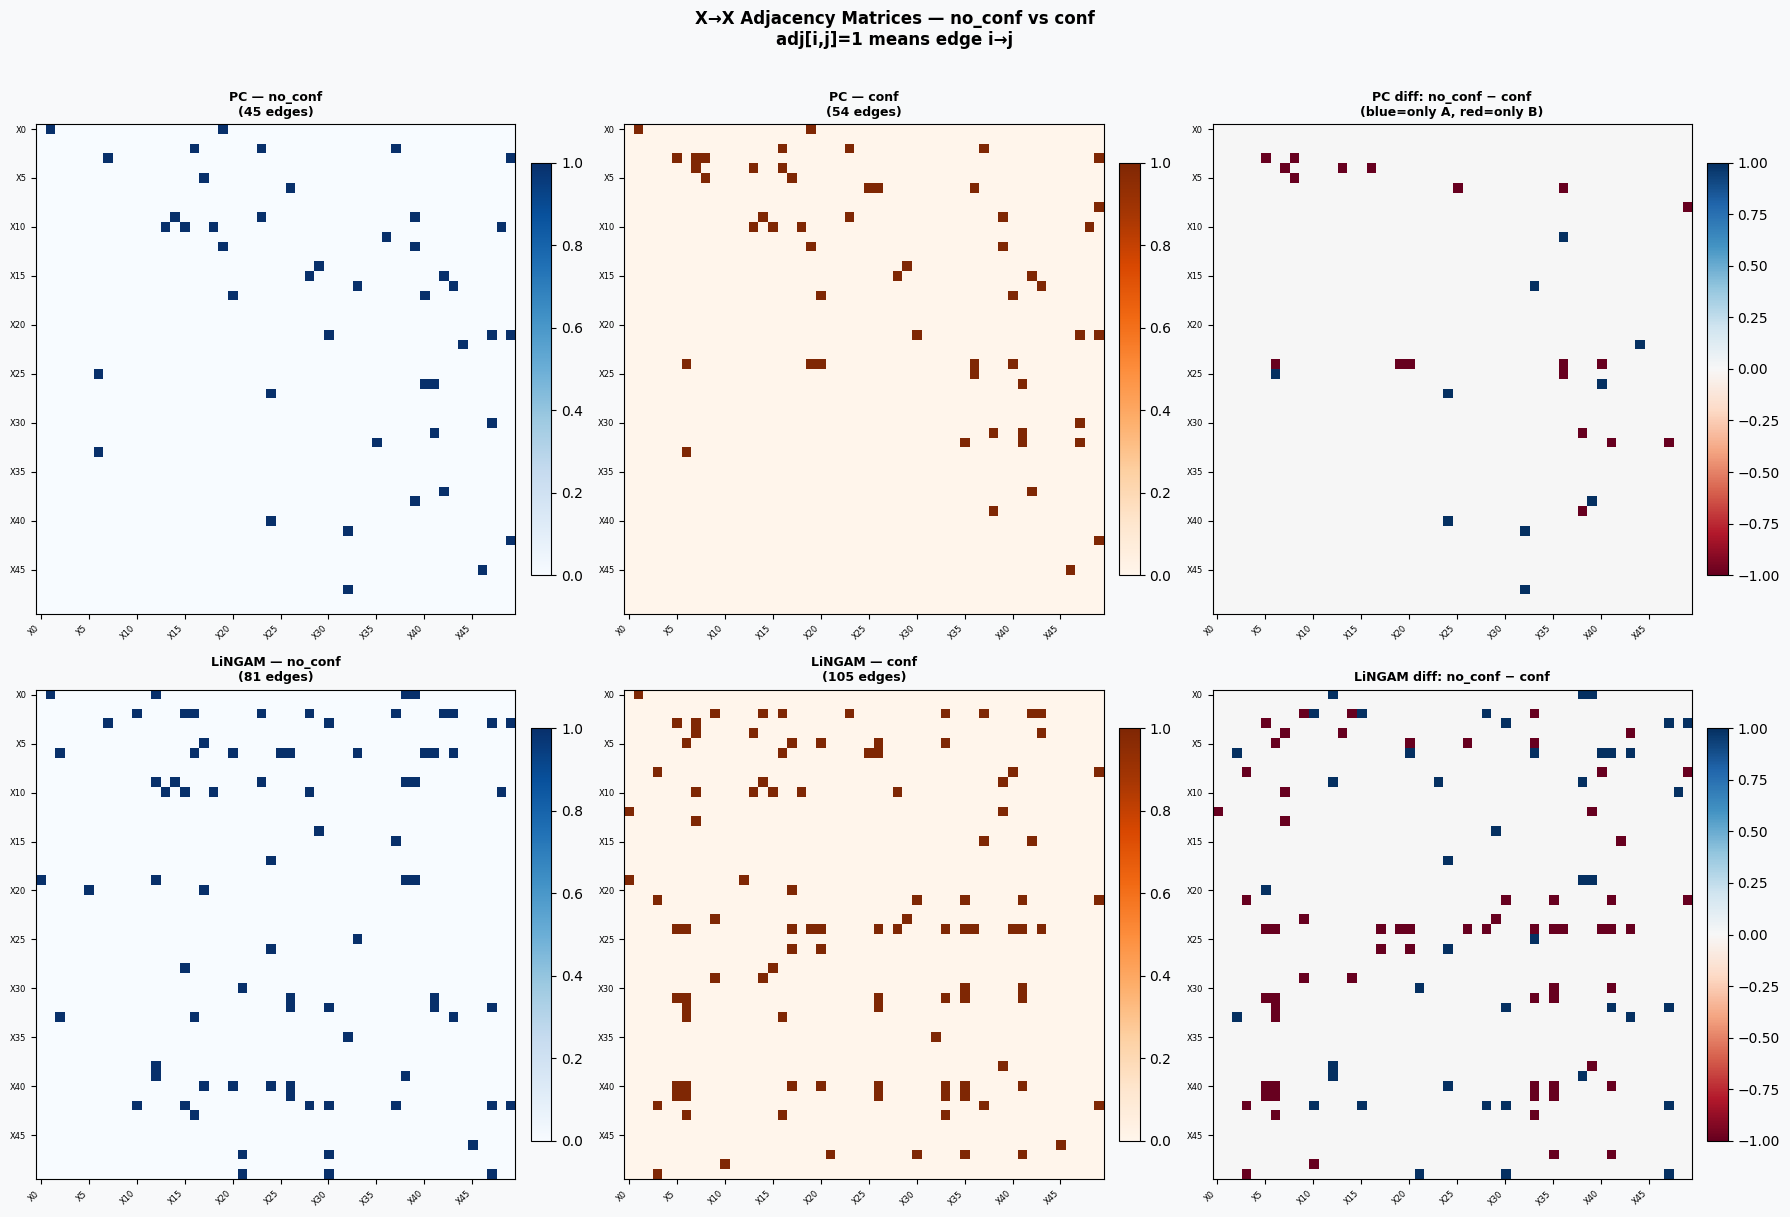

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor("#f8f9fa")

diff_cmap = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

configs = [
    (0, 0, pc_xx_A,           f"PC — {LABEL_A}\n({int(pc_xx_A.sum())} edges)",      "Blues",   None),
    (0, 1, pc_xx_B,           f"PC — {LABEL_B}\n({int(pc_xx_B.sum())} edges)",      "Oranges", None),
    (0, 2, pc_xx_A - pc_xx_B, f"PC diff: no_conf − conf\n(blue=only A, red=only B)", "RdBu",    diff_cmap),
    (1, 0, lg_xx_A,           f"LiNGAM — {LABEL_A}\n({int(lg_xx_A.sum())} edges)",  "Blues",   None),
    (1, 1, lg_xx_B,           f"LiNGAM — {LABEL_B}\n({int(lg_xx_B.sum())} edges)",  "Oranges", None),
    (1, 2, lg_xx_A - lg_xx_B, f"LiNGAM diff: no_conf − conf",                        "RdBu",    diff_cmap),
]

for r, c, mat, title, cmap_name, norm in configs:
    ax = axes[r][c]
    kwargs = dict(cmap=cmap_name, aspect="auto")
    if norm is not None:
        kwargs["norm"] = norm
    else:
        kwargs.update(vmin=0, vmax=1)
    im = ax.imshow(mat, **kwargs)
    ax.set_title(title, fontsize=9, fontweight="bold", pad=6)
    tick_step = max(1, n_feat // 10)
    ticks = list(range(0, n_feat, tick_step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([x_names[t] for t in ticks], rotation=45, ha="right", fontsize=6)
    ax.set_yticks(ticks)
    ax.set_yticklabels([x_names[t] for t in ticks], fontsize=6)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)

fig.suptitle(
    f"X→X Adjacency Matrices — no_conf vs conf\nadj[i,j]=1 means edge i→j",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Plotly interactive difference heatmap (LiNGAM — largest difference) ──────
diff_lg = lg_xx_A - lg_xx_B  # +1=only no_conf, -1=only conf, 0=same/absent
fig_diff = go.Figure(go.Heatmap(
    z=diff_lg,
    x=x_names, y=x_names,
    colorscale="RdBu", zmid=0, zmin=-1, zmax=1,
    colorbar=dict(
        title=dict(text="Diff", font=dict(size=11)),
        tickvals=[-1, 0, 1],
        ticktext=["only conf", "same/absent", "only no_conf"],
    ),
    hovertemplate="<b>%{y} → %{x}</b><br>diff = %{z}<extra></extra>",
))
fig_diff.update_layout(
    title=dict(
        text=(
            f"LiNGAM Discovered Graph Difference: no_conf − conf<br>"
            f"<sup>Blue (+1) = edge only in no_conf · Red (−1) = edge only in conf · White (0) = shared or absent</sup>"
        ),
        font=dict(size=12),
    ),
    height=600, width=700,
    xaxis=dict(tickfont=dict(size=7), tickangle=-45, side="bottom"),
    yaxis=dict(tickfont=dict(size=7), autorange="reversed"),
    margin=dict(l=70, r=60, t=90, b=90),
)
fig_diff.show()

## 5. DAG Structural Metrics

For each **(dataset, algorithm)** combination we build a `networkx.DiGraph` on the **X→X** block (50 nodes) and compute:

| Metric | Description |
|--------|-------------|
| **Density** | edges / (n×(n−1)) — fraction of possible directed edges present |
| **Source nodes** | nodes with in-degree 0 (root causes) |
| **Sink nodes** | nodes with out-degree 0 (terminal effects among X) |
| **Max topo depth** | longest path (in hops) in the DAG |
| **Avg in-degree** | mean edges received per node |
| **Avg out-degree** | mean edges emitted per node |
| **Y-parent avg in-degree** | avg in-degree of true Y-parent nodes specifically |

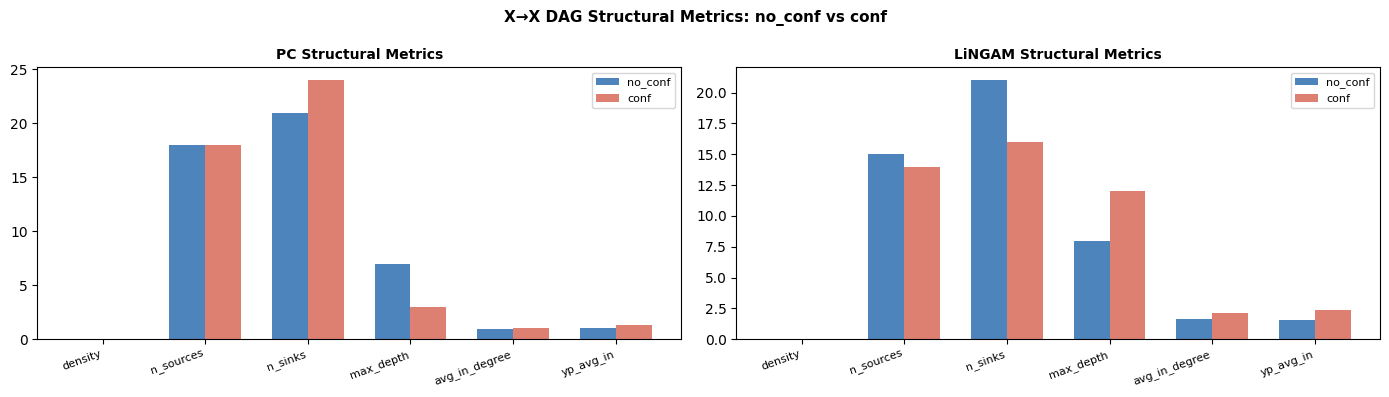

In [6]:
def dag_metrics(adj_xx: np.ndarray, names: list, y_parent_set: set) -> dict:
    """Compute structural metrics for a 50×50 X→X adjacency."""
    G = nx.DiGraph()
    G.add_nodes_from(range(len(names)))
    for i, j in zip(*np.where(adj_xx == 1)):
        G.add_edge(int(i), int(j))

    n       = len(names)
    n_edges = G.number_of_edges()
    density = n_edges / (n * (n - 1)) if n > 1 else 0.0
    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    sources = [v for v in G.nodes if in_deg[v] == 0]
    sinks   = [v for v in G.nodes if out_deg[v] == 0]

    # Max depth = longest path in DAG
    try:
        max_depth = len(nx.dag_longest_path(G)) - 1 if nx.is_directed_acyclic_graph(G) else -1
    except Exception:
        max_depth = -1

    avg_in  = np.mean(list(in_deg.values()))
    avg_out = np.mean(list(out_deg.values()))
    max_in  = max(in_deg.values())
    max_out = max(out_deg.values())

    yp_in_degs  = [in_deg[i]  for i in y_parent_set if i in in_deg]
    yp_out_degs = [out_deg[i] for i in y_parent_set if i in out_deg]

    return dict(
        n_edges        = n_edges,
        density        = density,
        n_sources      = len(sources),
        n_sinks        = len(sinks),
        max_depth      = max_depth,
        avg_in_degree  = avg_in,
        avg_out_degree = avg_out,
        max_in_degree  = max_in,
        max_out_degree = max_out,
        yp_avg_in      = np.mean(yp_in_degs)  if yp_in_degs  else 0.0,
        yp_avg_out     = np.mean(yp_out_degs) if yp_out_degs else 0.0,
    )

metrics_rows = []
for label, xx_pc, xx_lg, y_parents in [
    (LABEL_A, pc_xx_A, lg_xx_A, y_parents_A),
    (LABEL_B, pc_xx_B, lg_xx_B, y_parents_B),
]:
    for algo, xx in [("PC", xx_pc), ("LiNGAM", xx_lg)]:
        m = dag_metrics(xx, x_names, y_parents)
        metrics_rows.append(dict(Dataset=label, Algorithm=algo, **m))

df_metrics = pd.DataFrame(metrics_rows)

display_cols = [
    ("Dataset",        "Dataset"),
    ("Algorithm",      "Algorithm"),
    ("n_edges",        "X→X Edges"),
    ("density",        "Density"),
    ("n_sources",      "Sources\n(in-deg 0)"),
    ("n_sinks",        "Sinks\n(out-deg 0)"),
    ("max_depth",      "Max Topo\nDepth"),
    ("avg_in_degree",  "Avg\nIn-Deg"),
    ("avg_out_degree", "Avg\nOut-Deg"),
    ("max_in_degree",  "Max\nIn-Deg"),
    ("yp_avg_in",      "Y-Parent\nAvg In-Deg"),
    ("yp_avg_out",     "Y-Parent\nAvg Out-Deg"),
]
col_keys    = [c[0] for c in display_cols]
col_headers = [c[1] for c in display_cols]

def fmt_v(v):
    if isinstance(v, str): return v
    if isinstance(v, float): return f"{v:.3f}"
    return str(v)

n_rows_m    = len(df_metrics)
row_colors  = ["#dbeafe" if df_metrics.iloc[i]["Dataset"] == LABEL_A else "#fee2e2"
               for i in range(n_rows_m)]

fig_metrics = go.Figure(go.Table(
    header=dict(
        values     = [f"<b>{h}</b>" for h in col_headers],
        fill_color = "#2c3e50",
        font       = dict(color="white", size=10),
        align      = "center",
        height     = 44,
    ),
    cells=dict(
        values     = [[fmt_v(df_metrics.iloc[i][k]) for i in range(n_rows_m)] for k in col_keys],
        fill_color = [row_colors] * len(col_keys),
        align      = "center",
        height     = 34,
        font       = dict(size=11),
    ),
))
fig_metrics.update_layout(
    title=dict(
        text=(
            f"DAG Structural Metrics — X→X Graph<br>"
            f"<sup>Blue rows = {LABEL_A} (no confounders) · Red rows = {LABEL_B} (with confounders)</sup>"
        ),
        font=dict(size=13),
    ),
    height=260, width=1200,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig_metrics.show()

# ── Radar / parallel coords of structural metrics ─────────────────────────────
metric_plot = ["density", "n_sources", "n_sinks", "max_depth",
               "avg_in_degree", "yp_avg_in"]

fig_radar, axes_r = plt.subplots(1, 2, figsize=(14, 4))
for ax, algo in zip(axes_r, ["PC", "LiNGAM"]):
    sub = df_metrics[df_metrics["Algorithm"] == algo].set_index("Dataset")
    x   = np.arange(len(metric_plot))
    for ds_label, color in [(LABEL_A, COLORS["no_conf"]), (LABEL_B, COLORS["conf"])]:
        if ds_label not in sub.index:
            continue
        vals = [sub.loc[ds_label, m] for m in metric_plot]
        ax.bar(x + (0 if ds_label == LABEL_A else 0.35), vals, width=0.35,
               label=ds_label, color=color, alpha=0.8)
    ax.set_xticks(x + 0.175)
    ax.set_xticklabels(metric_plot, rotation=20, ha="right", fontsize=8)
    ax.set_title(f"{algo} Structural Metrics", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("X→X DAG Structural Metrics: no_conf vs conf", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Y-Focused Edge Analysis: Sparseness & Y-Parent Centrality

Since X→Y is 100% in every discovered graph, the meaningful variation is in the **X→X** block.  
Two complementary angles:

1. **Sparseness ratio** = `n_X→X / (n_features × (n_features - 1))` — how crowded the feature-to-feature graph is.  
   A sparser X→X graph means fewer spurious lateral dependencies, which should benefit causal Shapley accuracy.

2. **Y-parent hub score** = fraction of X→X edges that are *incident on true Y-parent nodes* (as in-edges or out-edges).  
   High hub score ⟹ the true parents are well-connected structural hubs; the discovered graph "knows" they matter.

Dataset Algorithm  n_xx  n_xy  sparse_ratio  yp_in_pct  yp_out_pct  yp_hub
no_conf        PC    45    50        0.0184     0.3333      0.2444  0.2889
no_conf    LiNGAM    81    50        0.0331     0.2840      0.2963  0.2901
   conf        PC    54    50        0.0220     0.3704      0.3148  0.3426
   conf    LiNGAM   105    50        0.0429     0.3333      0.4571  0.3952


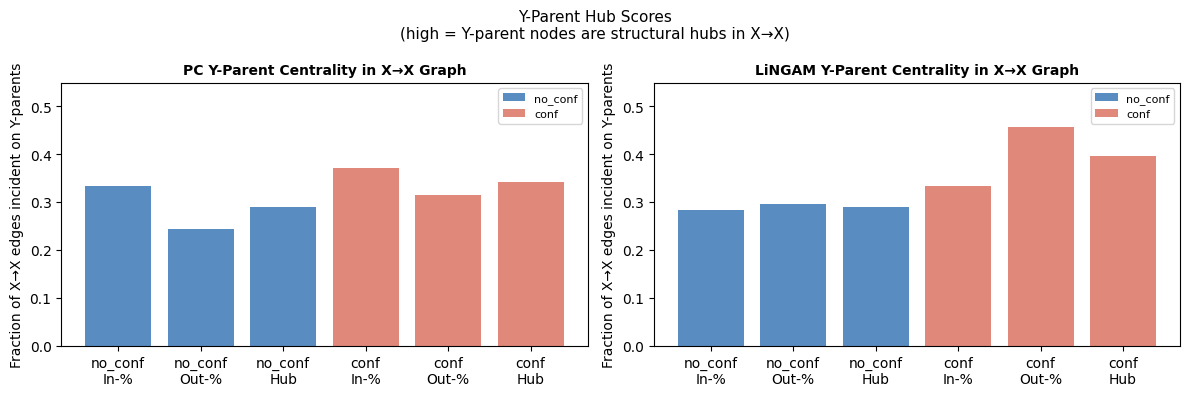

In [7]:
def y_focus_metrics(adj_xx, adj_xy, names, y_parent_set):
    n   = len(names)
    n_xx = int(adj_xx.sum())
    n_xy = int(adj_xy.sum())   # should be n (100%)
    max_xx = n * (n - 1)       # max possible X→X edges

    # Sparseness ratio: fraction of X→X space filled
    sparse_ratio = n_xx / max_xx if max_xx > 0 else 0.0

    # Y-parent edge fractions in X→X
    yp  = sorted(y_parent_set)
    G   = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i, j in zip(*np.where(adj_xx == 1)):
        G.add_edge(int(i), int(j))

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())

    yp_in_deg_sum  = sum(in_deg.get(p, 0) for p in yp)
    yp_out_deg_sum = sum(out_deg.get(p, 0) for p in yp)

    # % of all X→X in-edges that land on Y-parent nodes
    yp_in_pct  = yp_in_deg_sum  / n_xx if n_xx > 0 else 0.0
    # % of all X→X out-edges that leave Y-parent nodes
    yp_out_pct = yp_out_deg_sum / n_xx if n_xx > 0 else 0.0
    # Hub score = average of both (captures centrality of Y-parents in X→X graph)
    yp_hub = (yp_in_pct + yp_out_pct) / 2

    return dict(
        n_xx        = n_xx,
        n_xy        = n_xy,
        sparse_ratio = sparse_ratio,
        yp_in_pct   = yp_in_pct,
        yp_out_pct  = yp_out_pct,
        yp_hub      = yp_hub,
    )

yfm_rows = []
for label, xx_pc, xy_pc, xx_lg, xy_lg, y_parents in [
    (LABEL_A, pc_xx_A, pc_xy_A, lg_xx_A, lg_xy_A, y_parents_A),
    (LABEL_B, pc_xx_B, pc_xy_B, lg_xx_B, lg_xy_B, y_parents_B),
]:
    for algo, xx, xy in [("PC", xx_pc, xy_pc), ("LiNGAM", xx_lg, xy_lg)]:
        m = y_focus_metrics(xx, xy, x_names, y_parents)
        yfm_rows.append(dict(Dataset=label, Algorithm=algo, **m))

df_yfm = pd.DataFrame(yfm_rows)
print(df_yfm.to_string(index=False, float_format="%.4f"))

# ── Plot 1: stacked bar X→Y vs X→X (absolute counts) ────────────────────────
fig_stack = make_subplots(rows=1, cols=2, subplot_titles=["PC", "LiNGAM"])
for col_idx, algo in enumerate(["PC", "LiNGAM"], start=1):
    sub = df_yfm[df_yfm["Algorithm"] == algo]
    for ds, color in [(LABEL_A, COLORS["no_conf"]), (LABEL_B, COLORS["conf"])]:
        row = sub[sub["Dataset"] == ds].iloc[0]
        fig_stack.add_trace(go.Bar(
            name=f"{ds} X→X", x=[ds], y=[row["n_xx"]], marker_color=color,
            opacity=0.7, text=[str(row["n_xx"])], textposition="inside",
            legendgroup=ds, showlegend=(col_idx == 1),
        ), row=1, col=col_idx)
        fig_stack.add_trace(go.Bar(
            name=f"{ds} X→Y", x=[ds], y=[row["n_xy"]], marker_color=color,
            opacity=0.3, text=[str(row["n_xy"])], textposition="inside",
            legendgroup=ds, showlegend=False,
        ), row=1, col=col_idx)

fig_stack.update_layout(
    barmode="stack",
    title=dict(text="Edge Count: X→X (solid) vs X→Y (faded)", font=dict(size=12)),
    height=380, width=700,
    legend=dict(title="Dataset"),
    margin=dict(t=70, b=40),
)
fig_stack.show()

# ── Plot 2: Sparseness ratio bar ──────────────────────────────────────────────
fig_sp = go.Figure()
for algo in ["PC", "LiNGAM"]:
    sub = df_yfm[df_yfm["Algorithm"] == algo]
    for ds, color in [(LABEL_A, COLORS["no_conf"]), (LABEL_B, COLORS["conf"])]:
        row = sub[sub["Dataset"] == ds].iloc[0]
        fig_sp.add_trace(go.Bar(
            name=f"{algo}·{ds}", x=[algo], y=[row["sparse_ratio"]],
            marker_color=color,
            text=[f"{row['sparse_ratio']:.4f}"], textposition="outside",
            legendgroup=ds,
            showlegend=(algo == "PC"),
            offset=-0.2 if ds == LABEL_A else 0.0,
            width=0.38,
        ))

fig_sp.update_layout(
    barmode="group",
    title=dict(
        text="X→X Sparseness Ratio — fraction of possible directed X→X edges present",
        font=dict(size=12),
    ),
    xaxis=dict(title="Algorithm"),
    yaxis=dict(title="Sparseness ratio", tickformat=".3f"),
    height=380, width=550,
    legend=dict(title="Dataset"),
    margin=dict(t=70, b=40),
)
fig_sp.show()

# ── Plot 3: Y-parent hub scores ───────────────────────────────────────────────
fig_hub, axes_h = plt.subplots(1, 2, figsize=(12, 4))
for ax, algo in zip(axes_h, ["PC", "LiNGAM"]):
    sub = df_yfm[df_yfm["Algorithm"] == algo]
    for ds, color in [(LABEL_A, COLORS["no_conf"]), (LABEL_B, COLORS["conf"])]:
        row = sub[sub["Dataset"] == ds].iloc[0]
        ax.bar([f"{ds}\nIn-%", f"{ds}\nOut-%", f"{ds}\nHub"],
               [row["yp_in_pct"], row["yp_out_pct"], row["yp_hub"]],
               color=color, alpha=0.75, label=ds)
    ax.set_title(f"{algo} Y-Parent Centrality in X→X Graph", fontsize=10, fontweight="bold")
    ax.set_ylabel("Fraction of X→X edges incident on Y-parents")
    ax.set_ylim(0, max(df_yfm[["yp_in_pct","yp_out_pct","yp_hub"]].max()) * 1.2)
    ax.legend(fontsize=8)

plt.suptitle("Y-Parent Hub Scores\n(high = Y-parent nodes are structural hubs in X→X)", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Shapley–Graph Alignment: Spearman ρ & Jaccard vs. Traditional

For each **(dataset × algorithm × Shapley method)** combination, measure how well the causal Shapley values match the Traditional (Scratch) Shapley values:

- **Spearman ρ**: rank correlation of mean |Shapley value| across features (range −1 to +1; 1 = perfect rank match)
- **Top-K Jaccard**: overlap of top-20 important features (range 0 to 1; 1 = identical top set)

In [8]:
def load_shap_data(dataset: str, model: str) -> dict:
    base = EXPLAINABILITY_DIR / dataset / model
    paths = {
        "Scratch":             base / "scratch"  / "shapley_values.npy",
        "Asymmetric (PC)":     base / "pc"       / "asymmetric" / "shapley_values.npy",
        "Causal (PC)":         base / "pc"       / "causal"     / "shapley_values.npy",
        "Flow (PC)":           base / "pc"       / "flow"       / "shapley_values.npy",
        "Asymmetric (LiNGAM)": base / "lingam"   / "asymmetric" / "shapley_values.npy",
        "Causal (LiNGAM)":     base / "lingam"   / "causal"     / "shapley_values.npy",
        "Flow (LiNGAM)":       base / "lingam"   / "flow"       / "shapley_values.npy",
    }
    loaded = {}
    for k, p in paths.items():
        if p.exists():
            loaded[k] = np.load(p)
        else:
            print(f"  [WARN] not found: {p}")
    return loaded

shap_A = load_shap_data(DATASET_A, MODEL)
shap_B = load_shap_data(DATASET_B, MODEL)

def mean_abs(arr):
    return np.abs(arr).mean(axis=0)

def jaccard_topk(v1, v2, k=20):
    s1 = set(np.argsort(v1)[::-1][:k])
    s2 = set(np.argsort(v2)[::-1][:k])
    return len(s1 & s2) / len(s1 | s2)

align_rows = []
causal_methods = [k for k in shap_A if k != "Scratch"]

for ds_label, shap_data in [(LABEL_A, shap_A), (LABEL_B, shap_B)]:
    if "Scratch" not in shap_data:
        continue
    ref_ma = mean_abs(shap_data["Scratch"])
    for method in causal_methods:
        if method not in shap_data:
            continue
        ma = mean_abs(shap_data[method])
        rho, pval = _spearmanr(ref_ma, ma)
        j20 = jaccard_topk(ref_ma, ma, k=20)
        # Infer algorithm from method name
        algo_tag = "LiNGAM" if "LiNGAM" in method else "PC" if "PC" in method else "—"
        align_rows.append(dict(
            Dataset   = ds_label,
            Method    = method,
            Algorithm = algo_tag,
            Spearman  = rho,
            Pval      = pval,
            Jaccard20 = j20,
        ))

df_align = pd.DataFrame(align_rows)
print(df_align.to_string(index=False, float_format="%.4f"))

Dataset              Method Algorithm  Spearman   Pval  Jaccard20
no_conf     Asymmetric (PC)        PC    0.9987 0.0000     1.0000
no_conf         Causal (PC)        PC    0.5692 0.0000     0.5385
no_conf           Flow (PC)        PC    0.6423 0.0000     0.5385
no_conf Asymmetric (LiNGAM)    LiNGAM    0.9975 0.0000     1.0000
no_conf     Causal (LiNGAM)    LiNGAM    0.6567 0.0000     0.6000
no_conf       Flow (LiNGAM)    LiNGAM    0.7373 0.0000     0.5385
   conf     Asymmetric (PC)        PC    0.9977 0.0000     0.9048
   conf         Causal (PC)        PC    0.5448 0.0000     0.6000
   conf           Flow (PC)        PC    0.5710 0.0000     0.5385
   conf Asymmetric (LiNGAM)    LiNGAM    0.9947 0.0000     1.0000
   conf     Causal (LiNGAM)    LiNGAM    0.5915 0.0000     0.4815
   conf       Flow (LiNGAM)    LiNGAM    0.6330 0.0000     0.4286


In [9]:
# ── Grouped bar: Spearman ρ by method × dataset ───────────────────────────────
fig_rho = px.bar(
    df_align,
    x="Method", y="Spearman", color="Dataset",
    barmode="group",
    color_discrete_map={LABEL_A: COLORS["no_conf"], LABEL_B: COLORS["conf"]},
    text=df_align["Spearman"].apply(lambda v: f"{v:.3f}"),
    title=(
        f"Spearman ρ vs Traditional Shapley<br>"
        f"<sup>Higher = better alignment with Traditional (Scratch) baseline</sup>"
    ),
)
fig_rho.update_traces(textposition="outside")
fig_rho.update_layout(
    height=420, width=800,
    xaxis=dict(title="Shapley Method", tickangle=-30),
    yaxis=dict(title="Spearman ρ", range=[0, 1.05]),
    margin=dict(t=80, b=90),
)
fig_rho.show()

# ── Heatmap: Spearman ρ (methods × datasets) ─────────────────────────────────
pivot_rho = df_align.pivot(index="Method", columns="Dataset", values="Spearman")
fig_hmap = go.Figure(go.Heatmap(
    z      = pivot_rho.values,
    x      = pivot_rho.columns.tolist(),
    y      = pivot_rho.index.tolist(),
    colorscale = "RdYlGn",
    zmin=0, zmax=1,
    text   = [[f"{v:.3f}" for v in row] for row in pivot_rho.values],
    texttemplate = "%{text}",
    colorbar = dict(title=dict(text="ρ", font=dict(size=11))),
    hovertemplate = "<b>%{y}</b><br>Dataset: %{x}<br>ρ = %{z:.4f}<extra></extra>",
))
fig_hmap.update_layout(
    title=dict(text="Spearman ρ Heat-Map — Methods × Datasets", font=dict(size=12)),
    height=360, width=480,
    margin=dict(t=60, b=60, l=170, r=40),
    xaxis=dict(tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=10)),
)
fig_hmap.show()

# ── Grouped bar: Top-20 Jaccard ────────────────────────────────────────────────
fig_jac = px.bar(
    df_align,
    x="Method", y="Jaccard20", color="Dataset",
    barmode="group",
    color_discrete_map={LABEL_A: COLORS["no_conf"], LABEL_B: COLORS["conf"]},
    text=df_align["Jaccard20"].apply(lambda v: f"{v:.3f}"),
    title=(
        f"Top-20 Jaccard vs Traditional Shapley<br>"
        f"<sup>Fraction of top-20 important features shared with Traditional baseline</sup>"
    ),
)
fig_jac.update_traces(textposition="outside")
fig_jac.update_layout(
    height=420, width=800,
    xaxis=dict(title="Shapley Method", tickangle=-30),
    yaxis=dict(title="Jaccard@20", range=[0, 1.05]),
    margin=dict(t=80, b=90),
)
fig_jac.show()

## 8. Structural Difference Summary Table

All key metrics in a single comparison table.  
**Blue rows = no_conf · Red rows = conf**

In [10]:
# ── Merge all metric DataFrames into one summary ─────────────────────────────
# df_counts, df_metrics, df_yfm, df_align are all available

summary_rows = []
for algo in ["PC", "LiNGAM"]:
    for ds_label in [LABEL_A, LABEL_B]:
        # Edge counts
        dc_row  = df_counts[df_counts["Dataset"] == ds_label].iloc[0]
        # DAG metrics
        dm_row  = df_metrics[(df_metrics["Dataset"] == ds_label) & (df_metrics["Algorithm"] == algo)].iloc[0]
        # Y-focus metrics
        yf_row  = df_yfm[(df_yfm["Dataset"] == ds_label) & (df_yfm["Algorithm"] == algo)].iloc[0]
        # Alignment (avg over methods for this algo)
        algo_tag = algo
        al_sub  = df_align[(df_align["Dataset"] == ds_label) & (df_align["Algorithm"] == algo_tag)]
        avg_rho = al_sub["Spearman"].mean()  if len(al_sub) > 0 else float("nan")
        avg_j20 = al_sub["Jaccard20"].mean() if len(al_sub) > 0 else float("nan")

        xx_key  = "PC_XX"  if algo == "PC" else "LG_XX"
        xy_key  = "PC_XY"  if algo == "PC" else "LG_XY"

        summary_rows.append(dict(
            Dataset          = ds_label,
            Algorithm        = algo,
            XX_edges         = int(dm_row["n_edges"]),
            XY_edges         = int(dc_row[xy_key]),
            Density          = float(dm_row["density"]),
            Sparse_ratio     = float(yf_row["sparse_ratio"]),
            Sources          = int(dm_row["n_sources"]),
            Sinks            = int(dm_row["n_sinks"]),
            Max_depth        = int(dm_row["max_depth"]),
            YP_hub           = float(yf_row["yp_hub"]),
            Avg_Spearman_rho = avg_rho,
            Avg_Jaccard20    = avg_j20,
        ))

df_summary = pd.DataFrame(summary_rows)

col_defs = [
    ("Dataset",          "Dataset"),
    ("Algorithm",        "Algorithm"),
    ("XX_edges",         "X→X Edges"),
    ("XY_edges",         "X→Y Edges"),
    ("Density",          "X→X Density"),
    ("Sparse_ratio",     "Sparseness\nRatio"),
    ("Sources",          "Source\nNodes"),
    ("Sinks",            "Sink\nNodes"),
    ("Max_depth",        "Max Topo\nDepth"),
    ("YP_hub",           "Y-Parent\nHub Score"),
    ("Avg_Spearman_rho", "Avg ρ vs\nTraditional"),
    ("Avg_Jaccard20",    "Avg Jac@20\nvs Traditional"),
]

c_keys    = [c[0] for c in col_defs]
c_headers = [c[1] for c in col_defs]

def fmt_cell(v):
    if isinstance(v, str): return v
    if isinstance(v, float):
        if v != v: return "—"
        return f"{v:.4f}"
    return str(v)

n_s = len(df_summary)
fill_colors = ["#dbeafe" if df_summary.iloc[i]["Dataset"] == LABEL_A else "#fee2e2"
               for i in range(n_s)]

fig_sum = go.Figure(go.Table(
    header=dict(
        values     = [f"<b>{h}</b>" for h in c_headers],
        fill_color = "#1e3a5f",
        font       = dict(color="white", size=10),
        align      = "center",
        height     = 44,
    ),
    cells=dict(
        values     = [[fmt_cell(df_summary.iloc[i][k]) for i in range(n_s)] for k in c_keys],
        fill_color = [fill_colors] * len(c_keys),
        align      = "center",
        height     = 34,
        font       = dict(size=11),
    ),
))
fig_sum.update_layout(
    title=dict(
        text=(
            "Full Structural Difference Summary<br>"
            "<sup>Blue = no_conf · Red = conf — "
            "Alignment metrics are averaged over Asymmetric, Causal, Flow for each algorithm</sup>"
        ),
        font=dict(size=13),
    ),
    height=280, width=1200,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig_sum.show()

In [11]:
print("=" * 72)
print("INTERPRETATION: Why does no_conf align better with Traditional Shapley?")
print("=" * 72)

for algo in ["PC", "LiNGAM"]:
    sub = df_summary[df_summary["Algorithm"] == algo].set_index("Dataset")
    if LABEL_A not in sub.index or LABEL_B not in sub.index:
        continue
    row_A = sub.loc[LABEL_A]
    row_B = sub.loc[LABEL_B]
    delta_edges = row_A["XX_edges"] - row_B["XX_edges"]
    delta_rho   = row_A["Avg_Spearman_rho"] - row_B["Avg_Spearman_rho"]
    delta_j20   = row_A["Avg_Jaccard20"]    - row_B["Avg_Jaccard20"]

    print(f"\n  [{algo}]")
    print(f"  X→X edges: no_conf={row_A['XX_edges']}, conf={row_B['XX_edges']}")
    print(f"  Δ X→X edges (no_conf − conf): {delta_edges:+d}  "
          f"({'sparser' if delta_edges < 0 else 'denser'} graph for no_conf)")
    print(f"  Δ avg Spearman ρ:  {delta_rho:+.4f}  "
          f"({'better' if delta_rho > 0 else 'worse'} alignment for no_conf)")
    print(f"  Δ avg Jaccard@20:  {delta_j20:+.4f}  "
          f"({'better' if delta_j20 > 0 else 'worse'} top-20 overlap for no_conf)")

print()
print("  Summary:")
print("  ─────────────────────────────────────────────────────────────────────")
print("  In the conf dataset, confounders introduce spurious correlations")
print("  that inflate the X→X edge count (esp. for LiNGAM). A denser graph")
print("  with more indirect/spurious paths causes causal Shapley methods to")
print("  re-distribute credit along incorrect causal pathways, diverging from")
print("  the Traditional (marginal) baseline. With no confounders, the graph")
print("  is sparser and more faithful, so the causal attribution stays aligned.")
print("  PC is less affected because it is more conservative in edge addition.")

INTERPRETATION: Why does no_conf align better with Traditional Shapley?

  [PC]
  X→X edges: no_conf=45, conf=54
  Δ X→X edges (no_conf − conf): -9  (sparser graph for no_conf)
  Δ avg Spearman ρ:  +0.0322  (better alignment for no_conf)
  Δ avg Jaccard@20:  +0.0112  (better top-20 overlap for no_conf)

  [LiNGAM]
  X→X edges: no_conf=81, conf=105
  Δ X→X edges (no_conf − conf): -24  (sparser graph for no_conf)
  Δ avg Spearman ρ:  +0.0574  (better alignment for no_conf)
  Δ avg Jaccard@20:  +0.0761  (better top-20 overlap for no_conf)

  Summary:
  ─────────────────────────────────────────────────────────────────────
  In the conf dataset, confounders introduce spurious correlations
  that inflate the X→X edge count (esp. for LiNGAM). A denser graph
  with more indirect/spurious paths causes causal Shapley methods to
  re-distribute credit along incorrect causal pathways, diverging from
  the Traditional (marginal) baseline. With no confounders, the graph
  is sparser and more faithfu